In [ ]:
# 3.4 Baseline Model and 3.5 Advanced ML Models training

from pyspark.ml.classification import LogisticRegression, LinearSVC
import numpy as np
import xgboost as xgb

trained_models = {}

lr = LogisticRegression(
    featuresCol="tfidf_features",
    labelCol="label",
    maxIter=30
)

lr_model = lr.fit(train_data)
trained_models["Logistic Regression"] = lr_model

svm = LinearSVC(
    featuresCol="tfidf_features",
    labelCol="label",
    maxIter=20
)

svm_model = svm.fit(train_data)
trained_models["Linear SVM"] = svm_model

train_pd = train_data.select("tfidf_features", "label").toPandas()

X_train = np.array([v.toArray() for v in train_pd["tfidf_features"]])
y_train = train_pd["label"]

xgb_model = xgb.XGBClassifier(
    n_estimators=30,
    max_depth=4,
    learning_rate=0.1,
    objective='binary:logistic'
)

xgb_model.fit(X_train, y_train)

trained_models["XGBoost"] = xgb_model


print(trained_models.keys())

dict_keys(['Logistic Regression', 'Linear SVM', 'XGBoost'])



--- Evaluating: Logistic Regression ---


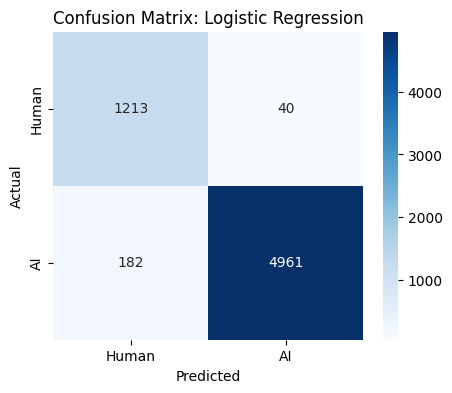


--- Evaluating: Linear SVM ---


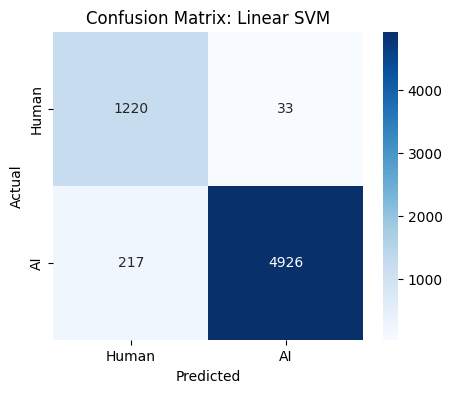


--- Evaluating: XGBoost ---


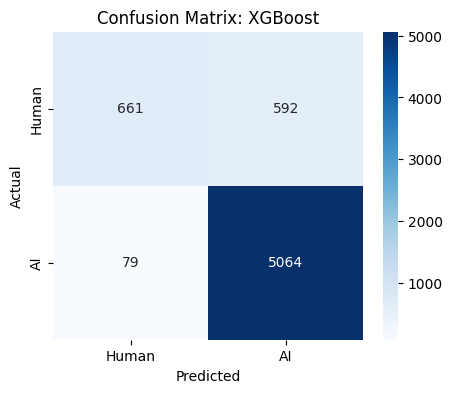


Final Evaluation Metrics Summary:
              Model  Accuracy  F1-Score  ROC-AUC
Logistic Regression  0.965291  0.965979 0.991042
         Linear SVM  0.960913  0.961894 0.993108
            XGBoost  0.895091  0.884081 0.000000


In [ ]:
# Task 4.3 Comprehensive Evaluation

from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

model_names = ["Logistic Regression", "Linear SVM", "XGBoost"]

def evaluate_models_fixed(models_dict, test_data):
    results = []
    target_feature_col = "tfidf_features"

    for name in model_names:
        print(f"\n--- Evaluating: {name} ---")
        model = models_dict[name]

        try:
            predictions = model.transform(test_data)
        except Exception:
            features_pd = test_data.select(target_feature_col).toPandas()
            X = np.stack(features_pd[target_feature_col].apply(lambda x: x.toArray()).values)
            y_pred = model.predict(X)

            from pyspark.sql import Row
            labels = test_data.select("label").toPandas()["label"].values
            predictions = spark.createDataFrame([Row(prediction=float(p), label=float(l))
                                               for p, l in zip(y_pred, labels)])

        acc_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
        f1_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

        accuracy = acc_eval.evaluate(predictions)
        f1_score = f1_eval.evaluate(predictions)

        roc_auc = 0.0
        try:
            if "probability" in predictions.columns:
                roc_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="probability", metricName="areaUnderROC")
                roc_auc = roc_eval.evaluate(predictions)
            elif "rawPrediction" in predictions.columns:
                roc_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
                roc_auc = roc_eval.evaluate(predictions)
        except:
            roc_auc = 0.0

        results.append({"Model": name, "Accuracy": accuracy, "F1-Score": f1_score, "ROC-AUC": roc_auc})

        y_true = predictions.select("label").toPandas()
        y_pred = predictions.select("prediction").toPandas()
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Human', 'AI'],
                    yticklabels=['Human', 'AI'])
        plt.title(f'Confusion Matrix: {name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

    return pd.DataFrame(results)

evaluation_df = evaluate_models_fixed(trained_models, test_data)
print("\nFinal Evaluation Metrics Summary:")
print(evaluation_df.to_string(index=False))